In [1]:
import torch
from torch import Tensor
import yaml
from models.vaectorgen import VAEctorGen
from models.vector_vae_nlayers import VectorVAEnLayers
from dataset import MNISTDataset
from PIL import Image
import matplotlib.pyplot as plt

/home/mfeuerpfeil/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
im2vec_config_path = "/home/mfeuerpfeil/master/thesis/configs/Im2Vec_mnist.yaml"
im2vec_model_path = "/scratch2/moritz_logs/Im2Vec_MNIST/checkpoints/last.ckpt"

vaectorgen_config_path = "/home/mfeuerpfeil/master/thesis/configs/VAEctorGen_mnist.yaml"
vaectorgen_model_path = "/scratch2/moritz_logs/VAEctorgen_mnist/checkpoints/last-v2.ckpt"

In [3]:
with open(im2vec_config_path, "r") as f:
    try:
        im2vec_config = yaml.safe_load(f)
    except yaml.YAMLError as exc:
        print(exc)

with open(vaectorgen_config_path, "r") as f:
    try:
        vaectorgen_config = yaml.safe_load(f)
    except yaml.YAMLError as exc:
        print(exc)

In [4]:
im2vec = VectorVAEnLayers(**im2vec_config["model_params"])
vaectorgen = VAEctorGen(**vaectorgen_config["model_params"])

using 1 paths
Using Differential Compositing
using 1 paths
Using Differential Compositing


In [5]:
def sample_to_image(sample:Tensor):
    if(sample.requires_grad):
        sample = sample.detach().cpu()
    
    # collapse batch-first dimension
    if(sample.shape[0] == 1):
        sample = sample.squeeze(0)

    # permute if new 0-th dimension is channels
    if(sample.shape[0] == 3 or sample.shape[0] == 4):
        return sample.permute(1,2,0)

    return sample

In [6]:
def show_images(image_tensor1, image_tensor2):
    fig, axs = plt.subplots(1, 2)
    axs[0].imshow(sample_to_image(image_tensor1))
    axs[1].imshow(sample_to_image(image_tensor2))
    plt.show()

# Reconstruction

In [7]:
ds = MNISTDataset(**im2vec_config["data_params"])
ds.setup()
dataloader = ds.test_dataloader()
imgs, labels = next(iter(dataloader))
with torch.no_grad():
    reconstructions = im2vec.generate(imgs)

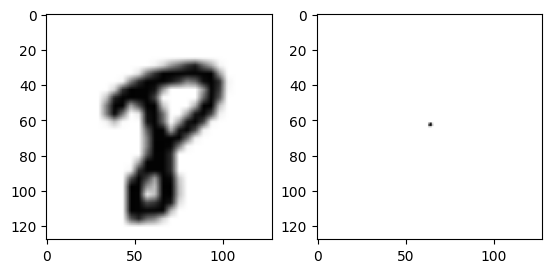

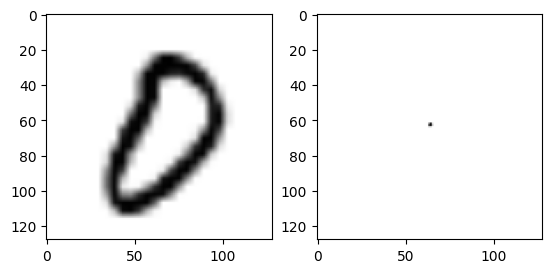

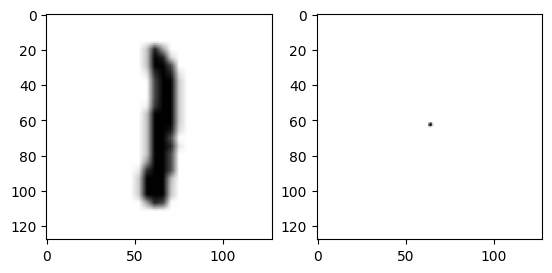

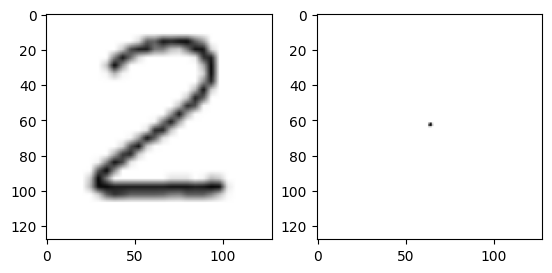

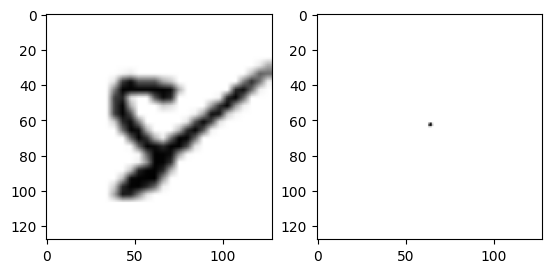

In [8]:
for i in range(5):
    show_images(imgs[i], reconstructions[i])

# Sampling

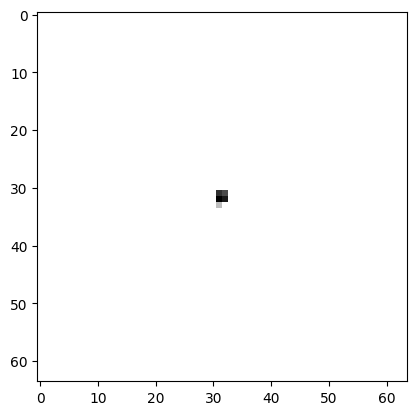

In [16]:
plt.imshow(sample_to_image(vaectorgen.sample(1, "cpu")))